In [ ]:
#30th Jun – Set up Seaborn environment and load percentage retention matrix

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Users/yash6/Internship 1/cleaned_retail_data_updated.csv", encoding='latin-1')
print(df.head())
print(df.shape)

   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country TransactionMonth  \
0  01-12-2010 08:26       2.55       17850  United Kingdom       01-12-2010   
1  01-12-2010 08:26       3.39       17850  United Kingdom       01-12-2010   
2  01-12-2010 08:26       2.75       17850  United Kingdom       01-12-2010   
3  01-12-2010 08:26       3.39       17850  United Kingdom       01-12-2010   
4  01-12-2010 08:26       3.39       17850  United Kingdom       01-12-2010   

  CohortMonth  CohortIndex  
0  01-12-2010          0.0  
1  01-12-2010          0.0  

In [3]:
cohort_data = (
    df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
      .nunique()
      .reset_index()
)

In [4]:
cohort_size = cohort_data[cohort_data["CohortIndex"] == 0][
    ["CohortMonth", "CustomerID"]
].rename(columns={"CustomerID": "CohortSize"})

In [5]:
cohort_data = cohort_data.merge(cohort_size, on="CohortMonth")
cohort_data["RetentionRate"] = (
    cohort_data["CustomerID"] /
    cohort_data["CohortSize"] * 100
)

In [6]:
retention_matrix = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="RetentionRate"
)
print(retention_matrix.head())

CohortIndex   0.0        1.0        2.0        3.0        4.0        5.0   \
CohortMonth                                                                 
01-01-2011   100.0  14.606742  13.483146  12.359551  19.662921  21.910112   
01-02-2011   100.0   9.473684  15.263158  13.684211  13.684211  11.052632   
01-03-2011   100.0   7.264957  13.247863  10.256410  10.683761  11.965812   
01-04-2011   100.0  12.068966  12.931034  12.068966  12.931034  12.068966   
01-05-2011   100.0  16.205534  11.067194  12.648221  12.648221  15.019763   

CohortIndex       6.0        7.0        8.0        9.0        10.0       11.0  \
CohortMonth                                                                     
01-01-2011   12.921348  15.168539  17.415730  19.662921  22.471910  15.730337   
01-02-2011   14.736842  17.894737  13.157895  19.473684  13.684211        NaN   
01-03-2011   14.102564  10.256410  15.811966  13.675214        NaN        NaN   
01-04-2011   12.500000  15.948276  11.206897        NaN

In [ ]:
#1st Jul – Plot basic Cohort Retention Heatmap

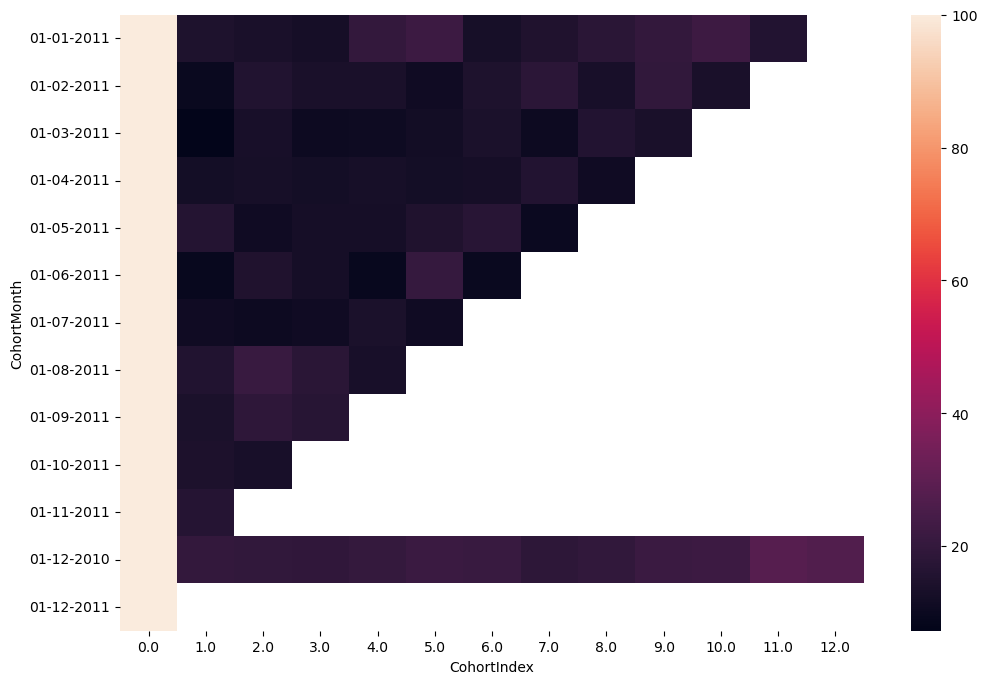

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(retention_matrix)
plt.show()

In [ ]:
#2nd Jul – Format Axis Labels

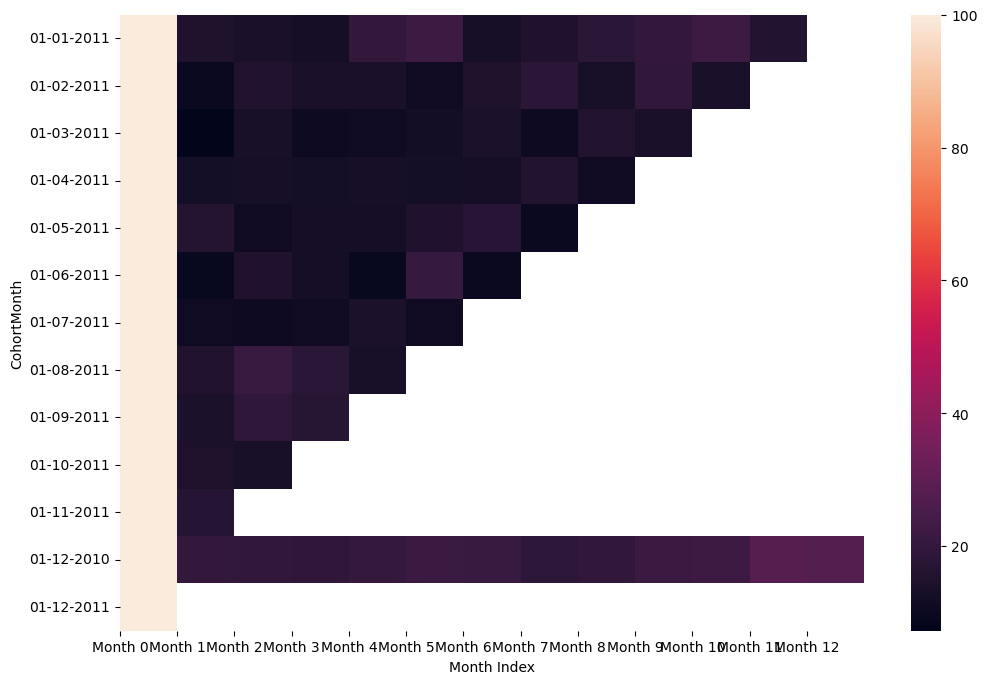

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(retention_matrix)
plt.xlabel("Month Index")
plt.ylabel("CohortMonth")
plt.xticks(
    range(len(retention_matrix.columns)),
    [f"Month {int(i)}" for i in retention_matrix.columns]
)
plt.show()

In [ ]:
#3rd Jul – Add Percentage Annotations

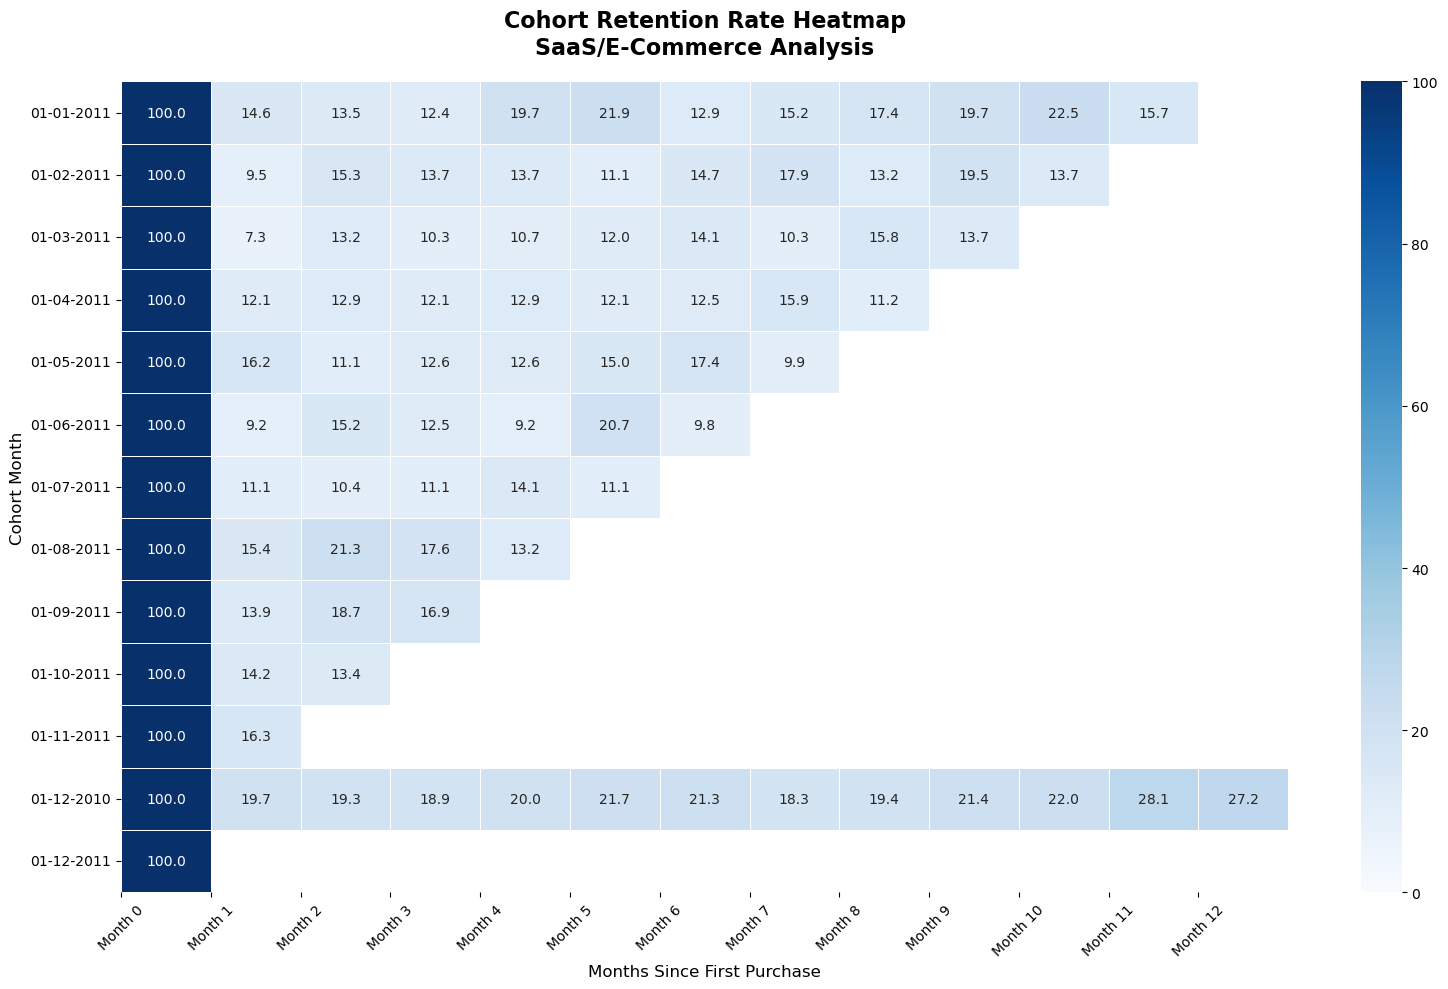

In [9]:
plt.figure(figsize=(16, 10))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    vmin=0,
    vmax=100
)
plt.title('Cohort Retention Rate Heatmap\nSaaS/E-Commerce Analysis', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.xticks(
    range(len(retention_matrix.columns)),
    [f"Month {int(i)}" for i in retention_matrix.columns],
    rotation=45
)
plt.tight_layout()
plt.show()

In [ ]:
#4th Jul – Final Heatmap & Export

✅ Heatmap saved as cohort_retention_heatmap.png


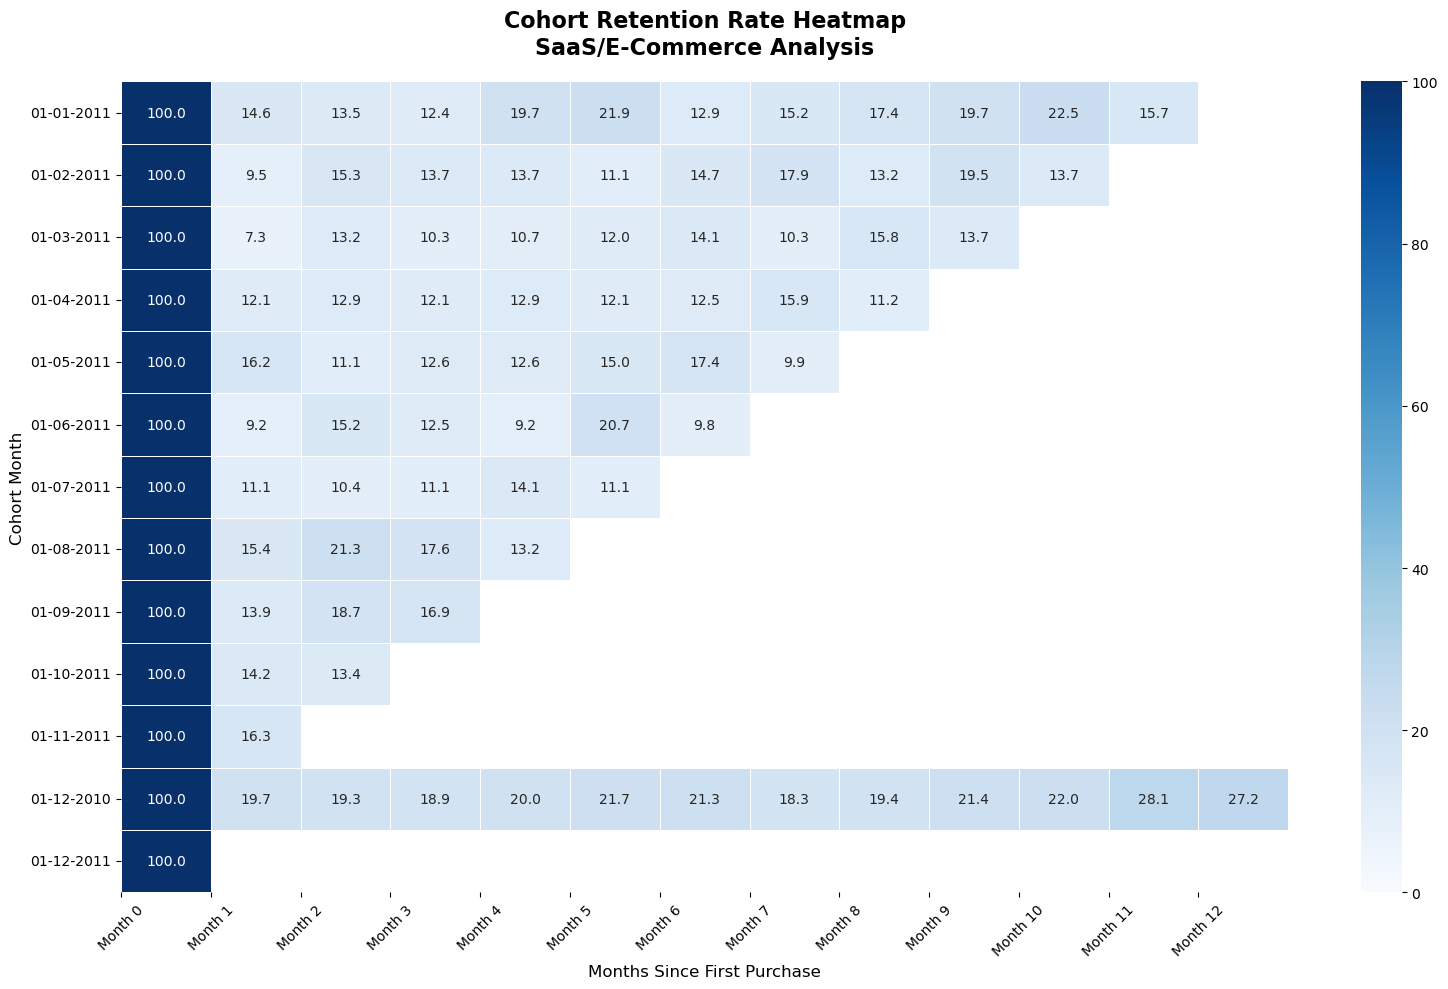

In [10]:
plt.figure(figsize=(16, 10))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    vmin=0,
    vmax=100
)
plt.title('Cohort Retention Rate Heatmap\nSaaS/E-Commerce Analysis',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.xticks(
    range(len(retention_matrix.columns)),
    [f"Month {int(i)}" for i in retention_matrix.columns],
    rotation=45
)
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Heatmap saved as cohort_retention_heatmap.png")